In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/ml/praktikum07/data/dataset_satelit.csv')
df.head()

,No,Longitude,Lattitude,N,P,K,Ca,Mg,Fe,Mn,...,b1,Sigma_VV,Sigma_VH,plia,lia,iafe,gamma0_vv,gamma0_vh,beta0_vv,beta0_vh
0,1,103.036658,-0.604417,2.64,0.15,0.415,0.51,0.31,119.96,463.23,...,0.0433,0.18183,0.04461,35.74446,35.79744,35.41161,0.22331,0.05479,0.31325,0.07686
1,2,103.037201,-0.604689,2.75,0.17,0.568,0.76,0.58,102.63,493.81,...,0.0465,0.22079,0.04640,35.12096,35.14591,35.41510,0.27116,0.05699,0.38033,0.07993
2,3,103.036359,-0.603012,1.77,0.12,0.339,0.49,0.6,107.37,460.93,...,0.0417,0.18926,0.03992,35.07724,35.07730,35.41135,0.23242,0.04902,0.32604,0.06876
3,4,103.036950,-0.603219,2.30,0.15,0.460,0.74,0.67,96.02,338.17,...,0.0367,0.14769,0.03622,36.08078,36.08469,35.41583,0.18138,0.04448,0.25440,0.06238
4,5,103.036802,-0.601969,2.05,0.14,0.308,0.64,0.72,87.01,384.33,...,0.0361,0.18205,0.03797,32.68855,32.69293,35.41592,0.22359,0.04664,0.31359,0.06541


In [ ]:
df.describe()

,No,Longitude,Lattitude,N,P,K,Ca,Fe,Mn,Cu,...,b1,Sigma_VV,Sigma_VH,plia,lia,iafe,gamma0_vv,gamma0_vh,beta0_vv,beta0_vh
count,594.000000,594.000000,594.000000,594.000000,594.000000,593.000000,594.000000,594.000000,594.000000,594.000000,...,594.000000,594.000000,594.000000,594.000000,594.000000,594.000000,594.000000,594.000000,594.000000,594.000000
mean,297.500000,106.878644,-1.024933,2.259091,0.141380,0.582175,0.595094,74.613771,308.034697,2.391195,...,0.177291,0.234474,0.102789,28.640422,28.664891,28.609569,0.202587,0.051524,0.269642,0.062320
std,171.617307,4.949840,0.965349,0.395499,0.019782,0.222567,0.366118,55.579655,241.731643,1.580296,...,0.155615,0.070516,0.112310,15.325347,15.380384,15.329170,0.104357,0.012959,0.143728,0.024218
min,1.000000,102.760857,-2.333750,1.140000,0.090000,0.122000,0.050000,21.080000,3.160000,0.090000,...,0.014100,0.115170,0.021460,0.127000,0.098600,0.026000,0.008700,0.016900,0.009300,0.016300
25%,149.250000,102.927811,-2.233338,1.982500,0.130000,0.429000,0.320000,40.705000,124.015000,1.172500,...,0.046925,0.183210,0.039535,31.959745,31.968948,33.685353,0.183085,0.040250,0.244935,0.052772
50%,297.500000,103.581969,-0.602276,2.280000,0.140000,0.549000,0.540000,65.650000,239.445000,2.225000,...,0.072700,0.213385,0.046550,35.067930,35.110415,34.611565,0.233590,0.050415,0.310380,0.068380
75%,445.750000,113.403797,-0.257349,2.570000,0.150000,0.710000,0.790000,87.372500,434.990000,3.357500,...,0.318900,0.262242,0.059190,38.319135,38.441065,39.002760,0.271790,0.060410,0.364505,0.079020
max,594.000000,113.434700,0.069251,3.230000,0.220000,1.489000,2.820000,559.100000,2009.320000,8.170000,...,0.751400,0.512210,0.373000,47.592900,48.014640,39.209330,0.658960,0.122300,0.814170,0.150620


In [ ]:
# Tentukan target dan fitur
y = df["N"]
X = df[["P", "K", "Ca", "Fe", "Mn", "Cu"]]

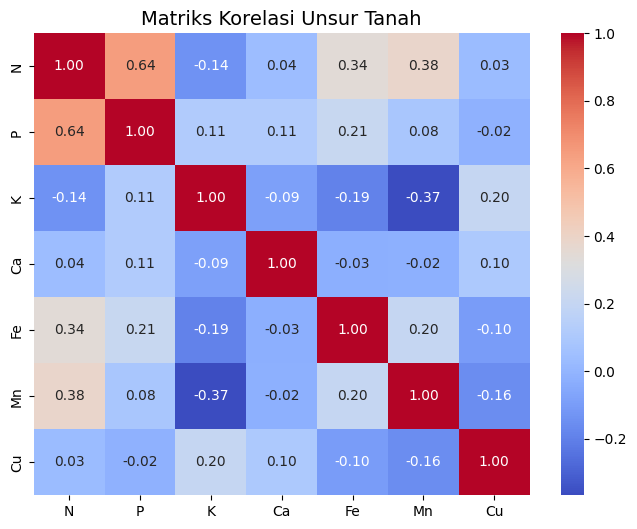

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ambil kolom yang relevan aja
corr = df[["N", "P", "K", "Ca", "Fe", "Mn", "Cu"]].corr()

# bikin ukuran figure biar jelas
plt.figure(figsize=(8,6))

# plot heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

# kasih judul
plt.title("Matriks Korelasi Unsur Tanah", fontsize=14)
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Jumlah data train:", len(X_train))
print("Jumlah data test :", len(X_test))


Jumlah data train: 475
Jumlah data test : 119


In [ ]:
import statsmodels.api as sm

X_train_const = sm.add_constant(X_train)
X_train_const.head()

,const,P,K,Ca,Fe,Mn,Cu
155,1.0,0.12,0.976,0.40,117.01,9.21,3.07
550,1.0,0.16,0.493,0.79,86.69,108.09,0.09
132,1.0,0.20,0.767,0.80,103.11,460.22,1.12
450,1.0,0.14,0.511,0.15,38.89,162.01,0.52
287,1.0,0.16,0.657,0.55,42.41,133.98,3.49


In [ ]:
# cek apakah ada NaN di X_train_const atau y_train
print("Cek NaN di X_train_const:\n", X_train_const.isnull().sum())
print("\nCek NaN di y_train:\n", y_train.isnull().sum())


Cek NaN di X_train_const:
 const    0
P        0
K        1
Ca       0
Fe       0
Mn       0
Cu       0
dtype: int64

Cek NaN di y_train:
 0


In [ ]:
# hapus baris yang ada NaN
X_train_const = X_train_const.dropna()
y_train = y_train.loc[X_train_const.index]


In [ ]:
# isi nilai NaN dengan rata-rata kolom
X_train_const = X_train_const.fillna(X_train_const.mean())


In [ ]:
import statsmodels.api as sm
# fit model OLS
model = sm.OLS(y_train, X_train_const).fit()

# tampilkan semua parameter
print('-----------------------------')
print(model.params)
print('-----------------------------')

# ambil nilai koefisien satu per satu
const = model.params['const']
x1 = model.params['P']
x2 = model.params['K']
x3 = model.params['Ca']
x4 = model.params['Fe']
x5 = model.params['Mn']
x6 = model.params['Cu']

# tampilkan persamaan regresi
print(f"y = {const:.3f} + ({x1:.3f})*P + ({x2:.3f})*K + ({x3:.3f})*Ca + ({x4:.3f})*Fe + ({x5:.3f})*Mn + ({x6:.3f})*Cu")


-----------------------------
const     0.325478
P        12.778484
K        -0.159207
Ca       -0.060926
Fe        0.000860
Mn        0.000474
Cu        0.019488
dtype: float64
-----------------------------
y = 0.325 + (12.778)*P + (-0.159)*K + (-0.061)*Ca + (0.001)*Fe + (0.000)*Mn + (0.019)*Cu


In [ ]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      N   R-squared:                       0.591
Model:                            OLS   Adj. R-squared:                  0.586
Method:                 Least Squares   F-statistic:                     112.7
Date:                Mon, 03 Nov 2025   Prob (F-statistic):           1.67e-87
Time:                        02:39:08   Log-Likelihood:                -20.840
No. Observations:                 474   AIC:                             55.68
Df Residuals:                     467   BIC:                             84.81
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3255      0.089      3.639      0.0

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# tambahkan konstanta ke data uji
X_test_const = sm.add_constant(X_test)

# prediksi nilai N
y_pred_test = model.predict(X_test_const)

# buat tabel hasil prediksi
hasil = pd.DataFrame({
    "P": X_test["P"].to_numpy(),
    "K": X_test["K"].to_numpy(),
    "Ca": X_test["Ca"].to_numpy(),
    "Fe": X_test["Fe"].to_numpy(),
    "Mn": X_test["Mn"].to_numpy(),
    "Cu": X_test["Cu"].to_numpy(),
    "N Aktual": y_test.to_numpy(),
    "N Prediksi": y_pred_test
})

# hitung selisih error (positif berarti overpredict)
hasil["Selisih Error"] = hasil["N Prediksi"] - hasil["N Aktual"]

# hitung akurasi tiap baris
denom = hasil["N Aktual"].replace(0, np.nan)  # hindari pembagian dengan 0
hasil["Akurasi (%)"] = (1 - (hasil["Selisih Error"].abs() / denom)).clip(lower=0, upper=1) * 100

# tampilkan beberapa baris hasil
hasil.head()


,P,K,Ca,Fe,Mn,Cu,N Aktual,N Prediksi,Selisih Error,Akurasi (%)
30,0.20,0.364,0.22,115.31,830.22,0.09,2.69,3.304035,0.614035,77.173426
299,0.17,1.397,0.86,40.23,80.98,2.87,2.28,2.351902,0.071902,96.846402
177,0.14,0.433,0.61,138.32,254.23,0.11,2.48,2.249901,-0.230099,90.721820
204,0.16,0.508,0.27,64.29,122.21,2.66,2.66,2.437730,-0.222270,91.643978
354,0.16,0.613,1.01,45.72,155.27,2.84,2.46,2.379126,-0.080874,96.712451
